# Results and Discussion: five-model comparison

Run after each model owner logs final results. Missing models stay missing. The bar chart and heatmap include available models only; complete the discussion once all five are present. This notebook reads `experiment_log.load_all_experiments()` and never trains models or chooses configurations from test scores.

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    %pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /Users/michael/Documents/school/nlp_language_technologies


In [2]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import config, data_loading, evaluation, experiment_log

logs = experiment_log.load_all_experiments()
# Re-running a notebook appends logs. Keep the latest record per named experiment/split.
logs = logs.drop_duplicates(["model", "experiment", "split"], keep="last")
# Explicit final records selected by owners, never a maximum over test results.
FINAL_RECORDS = {
    "logistic_regression": "final",
    "naive_bayes": "final",
    "cnn": "final_mean_of_seeds",
    "bilstm": "final_mean_of_seeds",
    "transformer": "final_mean_of_seeds",
}
metrics = ["macro_f1", "weighted_f1", "accuracy", "log_loss"]
class_metrics = [f"f1_{label}" for label in config.LABELS]
records = []
for model_name, final_name in FINAL_RECORDS.items():
    matching = logs[(logs.model == model_name) & (logs.split == "test") & (logs.experiment == final_name)]
    # Some owners logged only final_seed_N rows, so build the seed mean from them when no mean row exists.
    if matching.empty and final_name == "final_mean_of_seeds":
        seed_rows = logs[(logs.model == model_name) & (logs.split == "test") &
                         logs.experiment.str.fullmatch(r"final_seed_\d+", na=False)]
        if not seed_rows.empty:
            seed_summary = evaluation.summarise_scores(seed_rows[metrics + class_metrics].to_dict("records"))
            matching = pd.DataFrame([{**seed_rows.iloc[-1].to_dict(), **seed_summary}])
    if matching.empty:
        records.append({"model": model_name, "status": "pending"})
        continue
    row = matching.iloc[-1].to_dict()
    row["status"] = "available"
    # Count only exact final_seed_N rows: exclude uncalibrated and alternative configurations.
    seeds = logs[(logs.model == model_name) & (logs.split == "test") &
                logs.experiment.str.fullmatch(r"final_seed_\d+", na=False)]
    row["seed_runs"] = len(seeds) if final_name == "final_mean_of_seeds" else np.nan
    # Locate CV for the same configuration as the final record, without ranking test scores.
    final_settings = json.loads(row["settings"])
    cv = logs[(logs.model == model_name) & (logs.split == "cross_validation")]
    cv = cv[cv.settings.map(lambda s: json.loads(s) == final_settings)]
    if not cv.empty:
        row["cv_macro_f1"] = cv.iloc[-1]["macro_f1"]
        row["cv_macro_f1_std"] = cv.iloc[-1]["macro_f1_std"]
    records.append(row)
summary = pd.DataFrame(records).set_index("model")
for metric in metrics + class_metrics:
    for name in (metric, metric + "_std"):
        if name not in summary:
            summary[name] = np.nan
for name in ("cv_macro_f1", "cv_macro_f1_std", "seed_runs"):
    if name not in summary:
        summary[name] = np.nan

def format_score(mean, std):
    if pd.isna(mean):
        return "pending"
    return f"{mean:.4f} ± {std:.4f}" if pd.notna(std) else f"{mean:.4f} (single deterministic run)"

main_table = summary[["status", "seed_runs"]].copy()
for metric in metrics:
    main_table[metric] = [format_score(a, b) for a, b in zip(summary[metric], summary[metric + "_std"])]
main_table["CV macro-F1 (mean ± SD)"] = [
    f"{a:.4f} ± {b:.4f}" if pd.notna(a) and pd.notna(b) else "not logged / not applicable"
    for a, b in zip(summary.cv_macro_f1, summary.cv_macro_f1_std)
]
display(main_table)
output_directory = config.ROOT / "results" / "comparison"
output_directory.mkdir(parents=True, exist_ok=True)
main_table.to_csv(output_directory / "final_test_scores.csv")
summary.to_csv(output_directory / "final_test_scores_numeric.csv")
print("Pending models:", summary.index[summary.status == "pending"].tolist())

,status,seed_runs,macro_f1,weighted_f1,accuracy,log_loss,CV macro-F1 (mean ± SD)
model,,,,,,,
logistic_regression,available,NaN,0.7193 (single deterministic run),0.8709 (single deterministic run),0.8706 (single deterministic run),0.4649 (single deterministic run),0.6326 ± 0.0482
naive_bayes,available,NaN,0.6182 (single deterministic run),0.8555 (single deterministic run),0.8603 (single deterministic run),0.6539 (single deterministic run),0.5325 ± 0.0217
cnn,available,3.0,0.6939 ± 0.0103,0.8404 ± 0.0111,0.8378 ± 0.0117,0.4580 ± 0.0336,not logged / not applicable
bilstm,available,3.0,0.5218 ± 0.0084,0.8585 ± 0.0124,0.8646 ± 0.0124,0.4036 ± 0.0112,not logged / not applicable
transformer,available,3.0,0.7043 ± 0.1043,0.8969 ± 0.0101,0.8991 ± 0.0103,0.3165 ± 0.0075,not logged / not applicable


Pending models: []


## Macro-F1 and per-class performance

Error bars show sample SD across final seeds where logged. A deterministic baseline has one test score and no seed error bar. CV SD is shown separately in the main table because it measures variability across development folds, not variation on the fixed test set.

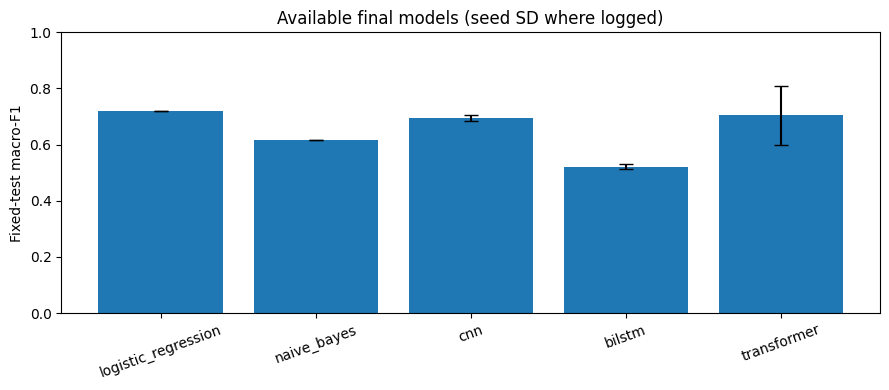

,kitaifa,michezo,biashara,kimataifa,burudani
model,,,,,
logistic_regression,0.8489 (single deterministic run),0.9412 (single deterministic run),0.8357 (single deterministic run),0.4706 (single deterministic run),0.5000 (single deterministic run)
naive_bayes,0.8365 (single deterministic run),0.9435 (single deterministic run),0.8111 (single deterministic run),0.0000 (single deterministic run),0.5000 (single deterministic run)
cnn,0.8010 ± 0.0174,0.9385 ± 0.0031,0.7947 ± 0.0168,0.4537 ± 0.0467,0.4815 ± 0.0321
bilstm,0.8384 ± 0.0096,0.9431 ± 0.0047,0.8272 ± 0.0312,0.0000 ± 0.0000,0.0000 ± 0.0000
transformer,0.8763 ± 0.0185,0.9586 ± 0.0041,0.8737 ± 0.0171,0.4794 ± 0.2466,0.3333 ± 0.2887


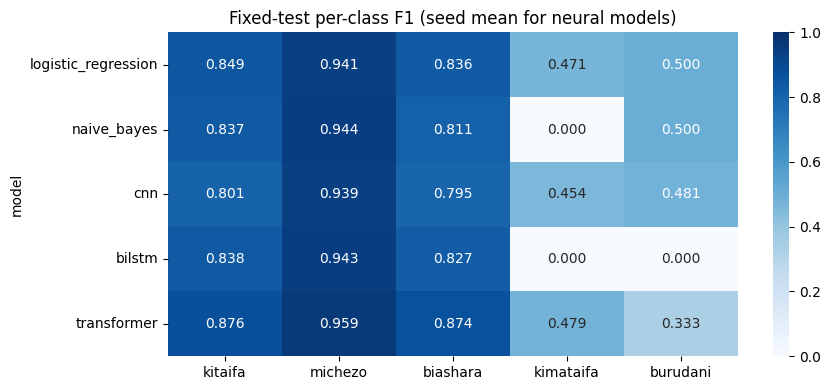

category
kitaifa      300
michezo      258
biashara     204
kimataifa      8
burudani       3
Name: test support, dtype: int64

In [3]:
available = summary[summary.status == "available"]
if not available.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(available.index, available.macro_f1,
           yerr=available.macro_f1_std.fillna(0), capsize=5)
    ax.set(ylabel="Fixed-test macro-F1", ylim=(0, 1), title="Available final models (seed SD where logged)")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(output_directory / "macro_f1_per_model.png", dpi=150)
    plt.show()
    per_class = available[class_metrics].rename(columns=lambda s: s.removeprefix("f1_"))
    per_class_table = pd.DataFrame(index=available.index)
    for label in config.LABELS:
        per_class_table[label] = [format_score(a, b) for a, b in
                                 zip(available[f"f1_{label}"], available[f"f1_{label}_std"])]
    display(per_class_table)
    per_class_table.to_csv(output_directory / "per_class_f1.csv")
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(per_class, annot=True, fmt=".3f", vmin=0, vmax=1, cmap="Blues", ax=ax)
    ax.set_title("Fixed-test per-class F1 (seed mean for neural models)")
    fig.tight_layout()
    fig.savefig(output_directory / "per_class_f1.png", dpi=150)
    plt.show()

test_support = data_loading.load_test()["category"].value_counts().reindex(config.LABELS)
display(test_support.rename("test support"))

## Full development CV comparison

Every baseline candidate has a mean and SD. This table is distinct from the five final test scores.

In [4]:
cv_columns = ["model", "experiment", "macro_f1", "macro_f1_std", "weighted_f1", "weighted_f1_std"]
cv_columns += [column for label in config.LABELS for column in (f"f1_{label}", f"f1_{label}_std")]
cv_table = logs.loc[logs.split == "cross_validation"].reindex(columns=cv_columns)
display(cv_table.sort_values(["model", "macro_f1"], ascending=[True, False]))
cv_table.to_csv(output_directory / "cross_validation_scores.csv", index=False)

,model,experiment,macro_f1,macro_f1_std,weighted_f1,weighted_f1_std,f1_kitaifa,f1_kitaifa_std,f1_michezo,f1_michezo_std,f1_biashara,f1_biashara_std,f1_kimataifa,f1_kimataifa_std,f1_burudani,f1_burudani_std
45,logistic_regression,char_balanced_C_0.1,0.6360,0.0557,0.8388,0.0114,0.7983,0.0122,0.9326,0.0130,0.8035,0.0135,0.4357,0.0767,0.2102,0.2883
43,logistic_regression,char_ngrams_balanced,0.6326,0.0482,0.8636,0.0097,0.8319,0.0125,0.9557,0.0072,0.8188,0.0183,0.4521,0.1074,0.1044,0.2221
49,logistic_regression,best_config,0.6326,0.0482,0.8636,0.0097,0.8319,0.0125,0.9557,0.0072,0.8188,0.0183,0.4521,0.1074,0.1044,0.2221
47,logistic_regression,char_balanced_C_10.0,0.6234,0.0460,0.8707,0.0083,0.8437,0.0105,0.9579,0.0071,0.8309,0.0151,0.2913,0.1555,0.1933,0.2907
37,logistic_regression,tune_C_0.1,0.5832,0.0140,0.8389,0.0073,0.7962,0.0094,0.9353,0.0106,0.8075,0.0101,0.3771,0.0723,0.0000,0.0000
35,logistic_regression,word_bigrams_balanced,0.5627,0.0134,0.8575,0.0084,0.8274,0.0106,0.9512,0.0076,0.8186,0.0161,0.2163,0.0678,0.0000,0.0000
39,logistic_regression,tune_C_1.0,0.5627,0.0134,0.8575,0.0084,0.8274,0.0106,0.9512,0.0076,0.8186,0.0161,0.2163,0.0678,0.0000,0.0000
41,logistic_regression,tune_C_10.0,0.5589,0.0147,0.8677,0.0081,0.8431,0.0094,0.9575,0.0050,0.8279,0.0148,0.1661,0.0762,0.0000,0.0000
33,logistic_regression,char_ngrams,0.5210,0.0059,0.8591,0.0093,0.8404,0.0100,0.9525,0.0064,0.8123,0.0189,0.0000,0.0000,0.0000,0.0000
29,logistic_regression,word_unigrams,0.5181,0.0068,0.8546,0.0108,0.8341,0.0111,0.9539,0.0074,0.8027,0.0201,0.0000,0.0000,0.0000,0.0000


## Discussion to finish after all five models

Use the exported scores and the EDA evidence rather than inventing results for pending models:

- Connect imbalance and tiny rare-class support (EDA §3) to the gap between weighted and macro-F1. Compare ComplementNB against MNB at the **same alpha**, using both rare-class F1 means and SDs.
- Connect frequent function words and distinctive topic words (EDA §7) to counts versus TF-IDF. Connect sparse vocabulary and Swahili word formation (EDA §6) to alpha and bigrams; do not assume phrase features must help topic classification.
- EDA §4 reports long articles. [Wang and Manning (2012)](https://aclanthology.org/P12-2018/) found SVMs outperform NB on longer reviews and NB stronger on short sentiment snippets. A logistic regression advantage here would be compatible with that finding, but is an extension to a different classifier, task and language, not a replication or proof that length caused the gap.
- [Rennie et al. (2003)](https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf) motivate complement estimates for skewed data. Improvement is an empirical question, especially with very few entertainment examples.
- Discuss sequence models' truncation and contextual features alongside EDA §§4–6 and their recorded training/calibration settings. A large seed SD limits claims based on a small mean difference. Overlapping CV folds do not justify significance claims from SD alone.

[MasakhaNEWS, Table 3](https://arxiv.org/html/2304.09972) reports **weighted F1**, averaged over five runs: Swahili count-based Naive Bayes scores 76.6 F1 points. Compare our weighted F1 × 100 for context only. MasakhaNEWS has different data, labels, splits and content conventions; our macro-F1 cannot be ranked directly against its weighted F1, and even matching the metric does not make the datasets equivalent.